In [2]:
import torch
import torch.nn as nn
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
from tqdm.notebook import tqdm
import os
import matplotlib.pyplot as plt
import random
import numpy as np
import openai
import re
from tqdm import tqdm
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from tqdm_joblib import tqdm_joblib
import pickle
from random import randint
import random
import json
import pandas as pd
import io

In [14]:
image_set = "utzap"

In [11]:
# import os
# from PIL import Image

# image_folder = "farfetch/cutout-img/cutout"
# images = []

# for filename in tqdm(os.listdir(image_folder)):
#     if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tiff")):
#         path = os.path.join(image_folder, filename)
#         with Image.open(path) as img:
#             images.append(img.copy())  # copy to keep it after file is closed

In [15]:
import os
from PIL import Image

image_folder = "utzap/img/ut-zap50k-images-square"
images = []

for root, dirs, files in tqdm(os.walk(image_folder)):
    for filename in files:
        if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tiff")):
            path = os.path.join(root, filename)
            with Image.open(path) as img:
                images.append(img.copy())  # copy to keep it after file is closed

0it [00:00, ?it/s]

In [16]:
splits = [images[i::10] for i in range(10)]

In [17]:
for idx, part in enumerate(splits):
    with open(f"{image_set}/split_{idx}.pkl", "wb") as f:
        pickle.dump(part, f)

In [18]:
def make_image_square(img, fill_color=(255, 255, 255)):
    x, y = img.size
    size = max(x, y)
    new_img = Image.new('RGB', (size, size), fill_color)
    new_img.paste(img, ((size - x) // 2, (size - y) // 2))
    return new_img

In [19]:
def process_image(image):
    try:
        img = make_image_square(image)
        img = img.resize((448, 448))
        return img
    except Exception as e:
        print(f"Error processing: {e}")
        return "Error"

# # Parallel processing with joblib and tqdm
# with tqdm_joblib(desc="Processing images", total=len(images)):
#     images = Parallel(n_jobs=-1)(
#         delayed(process_image)(image) for image in images
#     )

In [20]:
for i in range(10):
    # Load one split
    with open(f"{image_set}/split_{i}.pkl", "rb") as f:
        images = pickle.load(f)
    
    # Parallel processing with joblib and tqdm
    with tqdm_joblib(desc="Processing images", total=len(images)):
        images = Parallel(n_jobs=-1)(
            delayed(process_image)(image) for image in images
        )

    with open(f"{image_set}/processed_split_{i}.pkl", "wb") as f:
        pickle.dump(images, f)

Processing images:   0%|          | 0/5007 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5007 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5007 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5007 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5007 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5007 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5006 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5006 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5006 [00:00<?, ?it/s]

Processing images:   0%|          | 0/5006 [00:00<?, ?it/s]

In [21]:
images_all = []
for i in tqdm(range(3)):
    with open(f"{image_set}/processed_split_{i}.pkl", "rb") as f:
        part = pickle.load(f)
    images_all.extend(part)

  0%|          | 0/3 [00:00<?, ?it/s]

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _embed_batch(model, processor, batch_images):
    """
    Worker function: preprocess a batch, run through model, normalize, return CPU tensor.
    """
    # CPU ↔ GPU pinning
    inputs = processor(images=batch_images, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu()

def embed_images(
    model_name: str,
    images: list,
    batch_size: int = 32,
    num_workers: int = -1,
    backend: str = "threading",
):
    # 1) Load model & processor
    model = CLIPModel.from_pretrained(model_name).to(device).eval()
    processor = CLIPProcessor.from_pretrained(model_name)

    # 2) Create list of image batches
    batches = [images[i : i + batch_size] for i in range(0, len(images), batch_size)]

    # 3) Run parallel with tqdm progress bar
    with tqdm_joblib(desc="Embedding batches", total=len(batches)) as progress_bar:
        results = Parallel(
            n_jobs=num_workers,
            backend=backend,
        )(
            delayed(_embed_batch)(model, processor, batch)
            for batch in batches
        )

    # 4) Concatenate results
    return torch.cat(results, dim=0)

def search_image_embeddings(text, embeddings, images, model, processor, top_k=10):
    # Encode the text
    text_inputs = processor(text=[text], return_tensors="pt", padding=True, truncation=True, max_length=77).to(embeddings.device)
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Normalize embeddings (if not already)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

    # Compute cosine similarity
    cos_sim = torch.matmul(embeddings, text_features.T).squeeze()  # shape: (num_images,)
    print(cos_sim)
    # Get top-k indices
    top_k = min(top_k, len(images))
    top_values, top_indices = torch.topk(cos_sim, k=top_k)

    return [(i.item(), top_values[j].item()) for j, i in enumerate(top_indices)]

In [23]:
image_embeddings_fashionclip = embed_images("patrickjohncyh/fashion-clip", images_all, batch_size=32)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding batches:   0%|          | 0/470 [00:00<?, ?it/s]

In [24]:
remove_indices = []

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

tensor([0.2354, 0.2157, 0.2136,  ..., 0.2125, 0.2087, 0.1907])


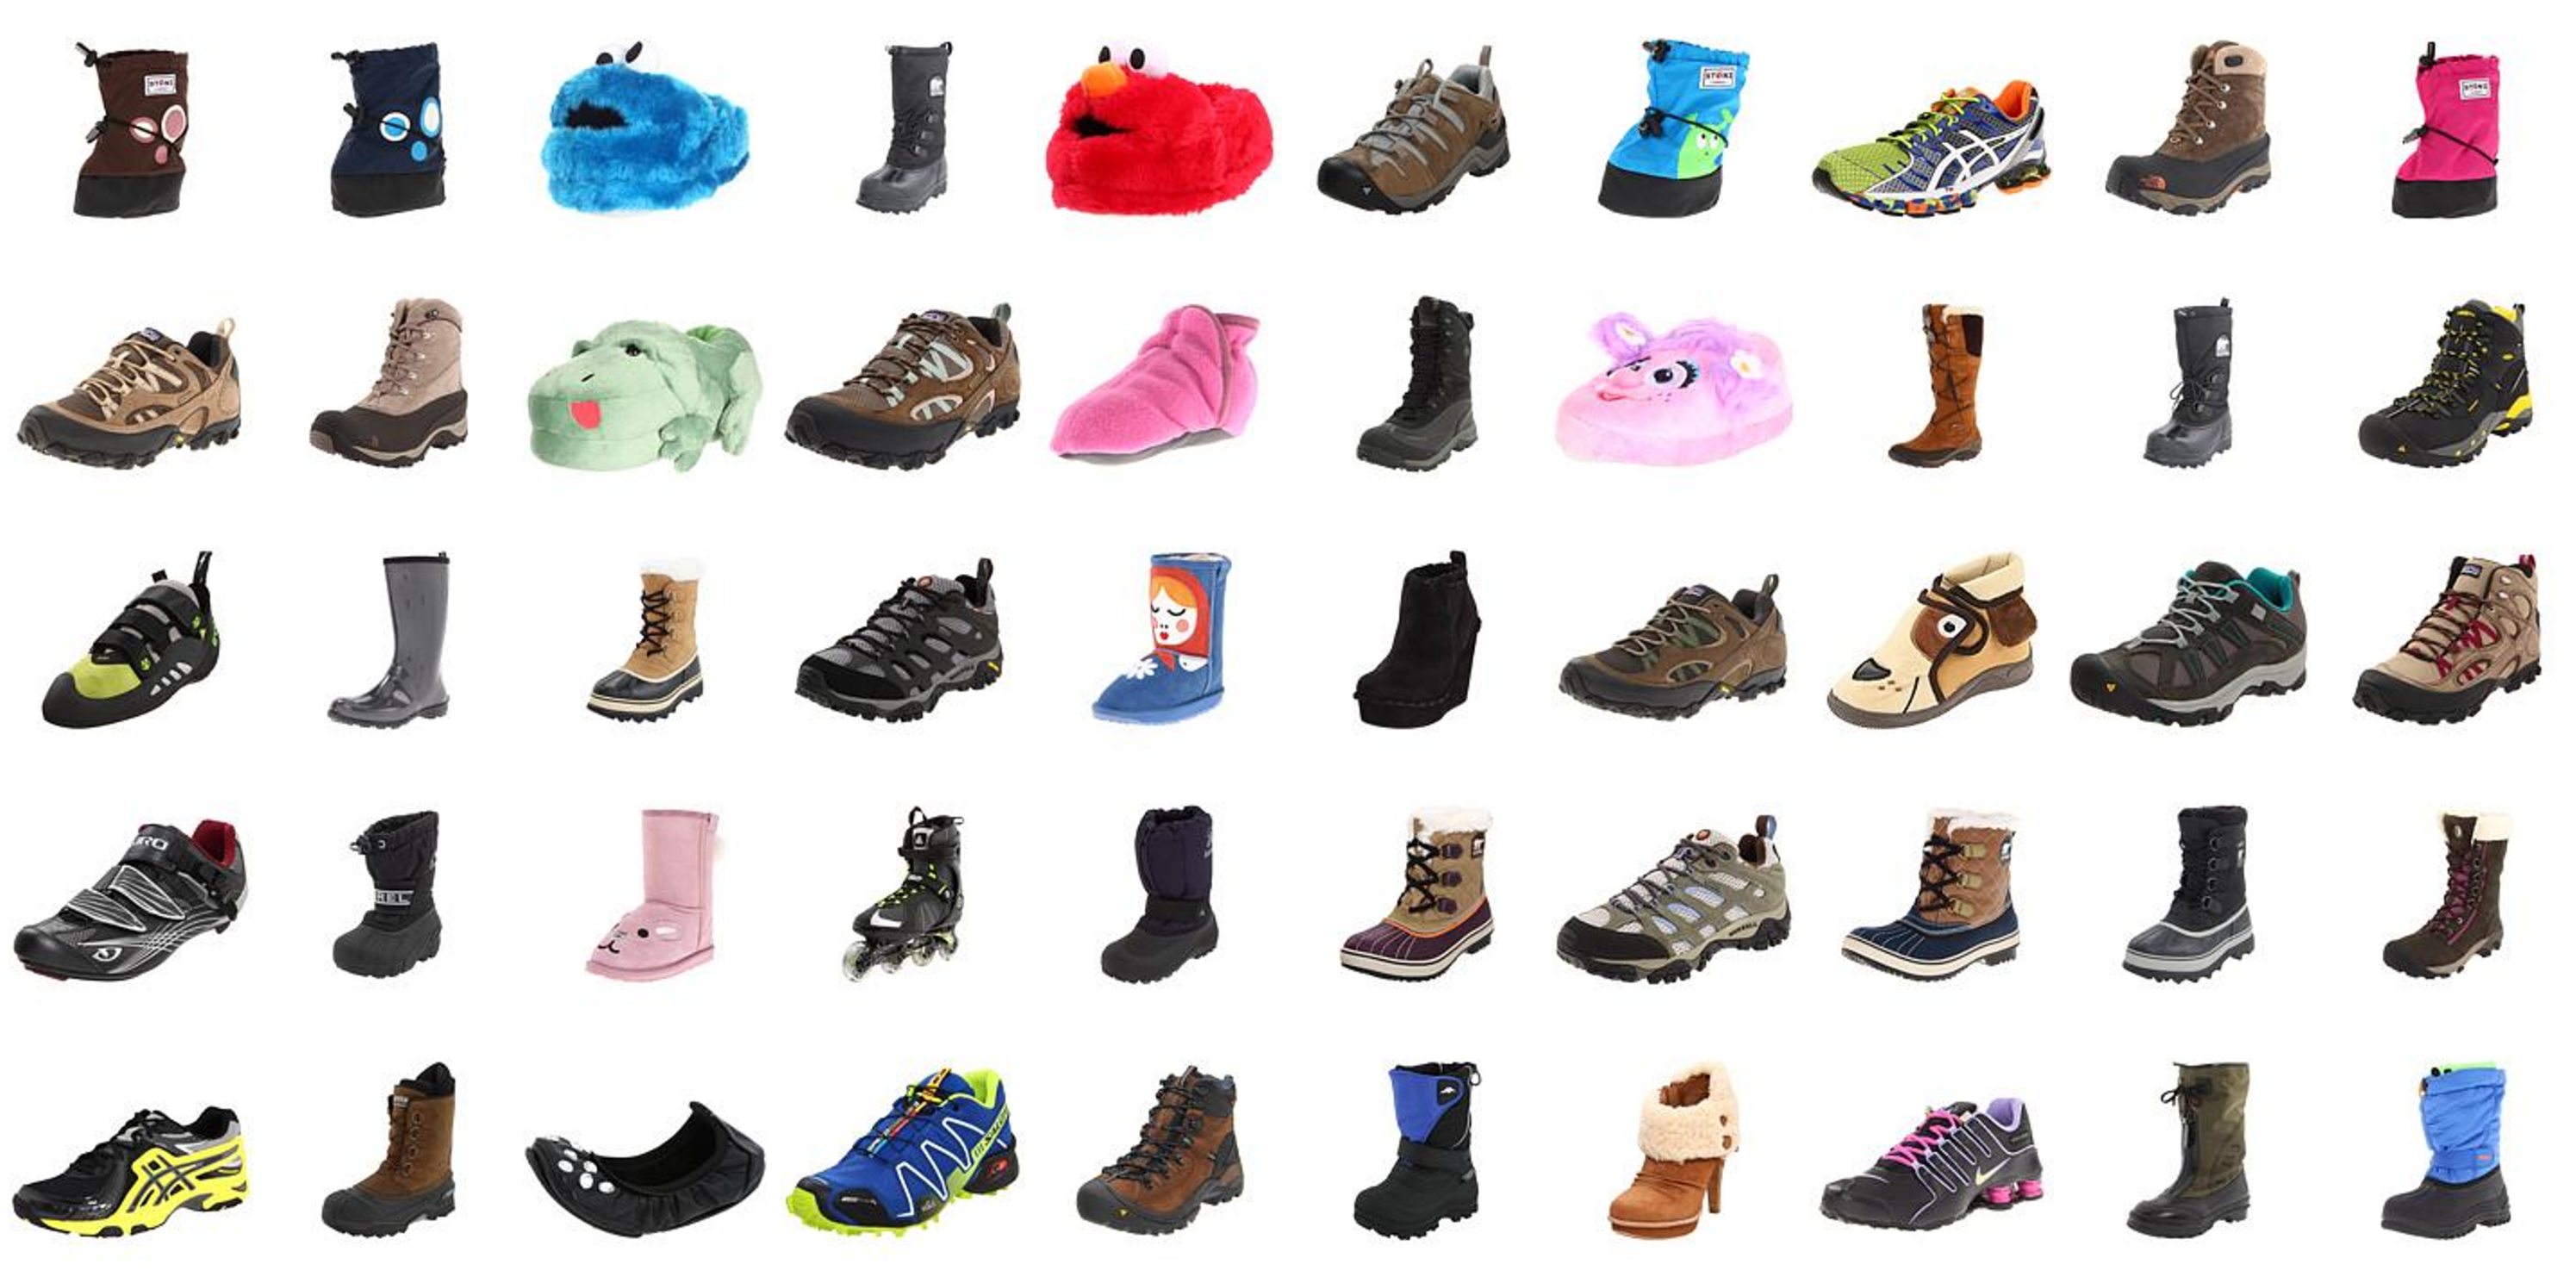

In [25]:
import matplotlib.pyplot as plt
import math
from transformers import CLIPModel, CLIPProcessor

query = "face"
model_fashionclip = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip")
processor_fashionclip = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
top_images_indices = [pair[0] for pair in search_image_embeddings(query, image_embeddings_fashionclip, images_all, model_fashionclip, processor_fashionclip, top_k=50)]

n = len(top_images_indices)
cols = min(10, n)
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

if n == 1:
    axes = [axes]
elif rows == 1:
    axes = axes
else:
    axes = axes.flatten()

for i in range(n):
    axes[i].imshow(images_all[top_images_indices[i]])
    axes[i].axis('off')

for i in range(n, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [26]:
remove_indices.extend(top_images_indices)
remove_indices = list(set(remove_indices))  # Ensure uniqueness
print(len(images_all) - len(remove_indices))
images_all = [images_all[i] for i in range(len(images_all)) if i not in remove_indices]
image_embeddings_fashionclip = [image_embeddings_fashionclip[i] for i in range(len(image_embeddings_fashionclip)) if i not in remove_indices]
image_embeddings_fashionclip = torch.stack(image_embeddings_fashionclip)

14971


In [27]:
random.shuffle(images_all)

In [28]:
images_test = images_all[:4096]
images_val = images_all[4096:8192]
images_train = images_all[8192:]

In [29]:
len(images_train), len(images_val), len(images_test)

(6779, 4096, 4096)

In [30]:
del images_all  # Free up memory

In [31]:
from PIL import Image, ImageOps

def resize_with_padding(img, target_size, padding_color=(0, 0, 0)):
    """
    Resize an image to fit within target_size without cropping,
    padding the rest with the specified color.
    
    Args:
        img (PIL.Image): Input image.
        target_size (tuple): Desired (width, height).
        padding_color (tuple): RGB color for padding.

    Returns:
        PIL.Image: Resized image with padding.
    """
    # Resize image maintaining aspect ratio
    img.thumbnail(target_size)

    # Create new image with target size and padding color
    new_img = Image.new("RGB", target_size, padding_color)

    # Paste resized image onto center
    paste_x = (target_size[0] - img.size[0]) // 2
    paste_y = (target_size[1] - img.size[1]) // 2
    new_img.paste(img, (paste_x, paste_y))

    return new_img

In [32]:
images_test_ = []
for img in tqdm(images_test):
    resized_img = resize_with_padding(img, (224, 224), padding_color=(255, 255, 255))
    images_test_.append(resized_img)

images_val_ = []
for img in tqdm(images_val): 
    resized_img = resize_with_padding(img, (224, 224), padding_color=(255, 255, 255))
    images_val_.append(resized_img)

images_train_ = []
for img in tqdm(images_train):
    resized_img = resize_with_padding(img, (224, 224), padding_color=(255, 255, 255))
    images_train_.append(resized_img)

with open(f'{image_set}/images_test.pkl', 'wb') as f:
    pickle.dump(images_test_, f)
with open(f'{image_set}/images_val.pkl', 'wb') as f:
    pickle.dump(images_val_, f)
with open(f'{image_set}/images_train.pkl', 'wb') as f:
    pickle.dump(images_train_, f)

  0%|          | 0/4096 [00:00<?, ?it/s]

  0%|          | 0/4096 [00:00<?, ?it/s]

  0%|          | 0/6779 [00:00<?, ?it/s]

In [33]:
del images_test_
del images_val_
del images_train_

In [34]:
import pickle 

with open(f'{image_set}/images_test.pkl', 'rb') as f:
    images_test = pickle.load(f)
with open(f'{image_set}/images_val.pkl', 'rb') as f:
    images_val = pickle.load(f) 
with open(f'{image_set}/images_train.pkl', 'rb') as f:
    images_train = pickle.load(f)

In [35]:
processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip", use_fast=True)

def process_batch(batch):
    return processor(images=batch, return_tensors="pt").pixel_values

# Split images into batches of, say, 32
def chunked(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

def process_images(images):
    batches = list(chunked(images, 32))

    pixel_batches = Parallel(n_jobs=-1)(
        delayed(process_batch)(batch) for batch in tqdm(batches, desc="Batch processing")
    )

    # Concatenate all batches
    pixel_values = torch.cat(pixel_batches)
    return pixel_values

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [36]:
pixel_values_test = process_images(images_test)
pixel_values_val = process_images(images_val)
pixel_values_train = process_images(images_train)

Batch processing:   0%|          | 0/128 [00:00<?, ?it/s]

Batch processing:   0%|          | 0/128 [00:00<?, ?it/s]

Batch processing:   0%|          | 0/212 [00:00<?, ?it/s]

In [37]:
with open(f'{image_set}/pixel_values_test.pkl', 'wb') as f:
    torch.save(pixel_values_test, f)
with open(f'{image_set}/pixel_values_val.pkl', 'wb') as f:
    torch.save(pixel_values_val, f)
with open(f'{image_set}/pixel_values_train.pkl', 'wb') as f:
    torch.save(pixel_values_train, f)

In [38]:
import pickle

In [39]:
with open(f'{image_set}/pixel_values_test.pkl', 'rb') as f:
    pixel_values_test = torch.load(f, weights_only=False)
with open(f'{image_set}/pixel_values_val.pkl', 'rb') as f:
    pixel_values_val = torch.load(f, weights_only=False)
with open(f'{image_set}/pixel_values_train.pkl', 'rb') as f:
    pixel_values_train = torch.load(f, weights_only=False)

In [40]:
with open(f'{image_set}/images_test.pkl', 'rb') as f:
    images_test = pickle.load(f)
with open(f'{image_set}/images_val.pkl', 'rb') as f:
    images_val = pickle.load(f)
with open(f'{image_set}/images_train.pkl', 'rb') as f:
    images_train = pickle.load(f)

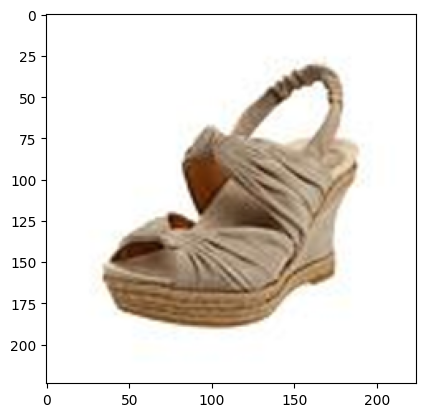

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.56902456..0.71529907].


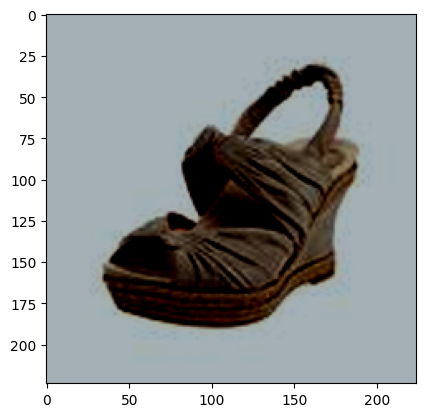

In [41]:
plt.imshow(images_test[0])
plt.show()
plt.imshow(pixel_values_test[0].permute(1, 2, 0).numpy()/3)
plt.show()

In [42]:
$

SyntaxError: invalid syntax (1334801704.py, line 1)

In [ ]:
with open('opencharacter/test_personas.json', 'r') as f:
    test_personas = json.load(f)
with open('opencharacter/validation_personas.json', 'r') as f:
    validation_personas = json.load(f)
with open('opencharacter/train_personas.json', 'r') as f:
    train_personas = json.load(f)

In [ ]:
len(test_personas), len(validation_personas), len(train_personas)

In [ ]:
from dotenv import load_dotenv

load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

In [ ]:
def embed_descriptions_openaitext(personas, batch_size=100):

    all_embeddings = []

    # Ensure all entries are strings
    personas = [str(p) for p in personas]

    for i in tqdm(range(0, len(personas), batch_size), desc="Embedding batches"):
        batch = personas[i:i + batch_size]

        try:
            response = openai.embeddings.create(
                input=batch,
                model="text-embedding-ada-002"
            )
            batch_embeddings = [item.embedding for item in response.data]
            all_embeddings.extend(batch_embeddings)
        except openai.error.OpenAIError as e:
            print(f"Batch {i}-{i + batch_size} failed: {e}")
            # Optional: retry logic can be added here

    return np.array(all_embeddings)

In [ ]:
test_persona_embeddings = torch.tensor(embed_descriptions_embed_descriptions_openaitextopenaitext(test_personas))
validation_persona_embeddings = torch.tensor((validation_personas))
train_persona_embeddings = torch.tensor(embed_descriptions_openaitext(train_personas))

In [ ]:
with open('opencharacter/openai/test_persona_embeddings.pkl', 'wb') as f:
    pickle.dump(test_persona_embeddings, f)
with open('opencharacter/openai/validation_persona_embeddings.pkl', 'wb') as f:
    pickle.dump(validation_persona_embeddings, f)
with open('opencharacter/openai/train_persona_embeddings.pkl', 'wb') as f:
    pickle.dump(train_persona_embeddings, f)

In [ ]:
$

In [ ]:
text_set = "nemotron"

In [ ]:
import json
with open(f'{text_set}/test_personas.json', 'r') as f:
    test_personas = json.load(f)
with open(f'{text_set}/validation_personas.json', 'r') as f:
    validation_personas = json.load(f)
with open(f'{text_set}/train_personas.json', 'r') as f:
    train_personas = json.load(f)

In [ ]:
from transformers import CLIPProcessor, CLIPModel
processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
def clip_text_embed(personas):
    text_inputs = processor.tokenizer(text=personas, return_tensors="pt", padding=True, truncation=True, max_length=77)
    with torch.no_grad():
        persona_embeddings = model.get_text_features(**text_inputs)
    return persona_embeddings

In [ ]:
# Embed validation personas in batches
batch_size = 128

def embed_personas_in_batches(personas, batch_size=128):
    all_embeddings = []
    for i in tqdm(range(0, len(personas), batch_size), desc="Embedding personas"):
        batch = personas[i:i+batch_size]
        emb = clip_text_embed(batch)
        all_embeddings.append(emb)
    return torch.cat(all_embeddings, dim=0)

train_persona_embeddings = embed_personas_in_batches(train_personas, batch_size)
validation_persona_embeddings = embed_personas_in_batches(validation_personas, batch_size)
test_persona_embeddings = embed_personas_in_batches(test_personas, batch_size)

Embedding personas:   0%|          | 0/40 [00:00<?, ?it/s]

Embedding personas:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding personas:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
with open(f'{text_set}/clip/test_persona_embeddings.pkl', 'wb') as f:
    pickle.dump(test_persona_embeddings, f)
with open(f'{text_set}/clip/validation_persona_embeddings.pkl', 'wb') as f:
    pickle.dump(validation_persona_embeddings, f)
with open(f'{text_set}/clip/train_persona_embeddings.pkl', 'wb') as f:
    pickle.dump(train_persona_embeddings, f)

In [ ]:
(validation_persona_embeddings.shape, train_persona_embeddings.shape, test_persona_embeddings.shape)

(torch.Size([1000, 512]), torch.Size([5000, 512]), torch.Size([1000, 512]))